# Tfh17 and B effector cell-cell interaction

- Test a few things 
1. run cell frequency correlation between Tfh17 and Beff
2. run cell chat 

In [1]:
# load library
quiet_library <- function(...) {
    suppressPackageStartupMessages(library(...))
}

quiet_library('tidyverse')
quiet_library('ggplot2')
quiet_library('CellChat')
quiet_library('patchwork')
quiet_library('SeuratDisk')
quiet_library('presto')

Warning message:
“Your system is mis-configured: ‘/var/db/timezone/localtime’ is not a symlink”
Warning message:
“‘/var/db/timezone/localtime’ is not identical to any known timezone file”
Warning message:
“Failed to locate timezone database”


In [2]:
# define working path
# define path 
data_path = '/home/workspace/private/ra-cohort-ide/ALTRA_revision/cell_interaction'
fig_path = '/home/workspace/private/ra-cohort-ide/ALTRA_revision/cell_interaction/figures'
output_path = '/home/workspace/private/ra-cohort-ide/ALTRA_revision/cell_interaction'
proj_name = 'ALTRA_TB_interact_'

if(!dir.exists(fig_path)) (dir.create(fig_path, recursive = TRUE))
if(!dir.exists(output_path)) (dir.create(output_path, recursive = TRUE))

In [3]:
# convert h5ad to h5seurat
# Convert(file.path(data_path, 'ALTRA_aim3_T_B_mem_cells.h5ad'), assay = 'RNA',
#         dest = "h5seurat", overwrite = TRUE)

In [5]:
tb_so <- LoadH5Seurat(file.path(data_path, 'ALTRA_aim3_T_B_mem_cells.h5seurat'), assays = 'RNA', meta.data = FALSE)
tb_so

Validating h5Seurat file

Initializing RNA with data

Adding counts for RNA

Adding feature-level metadata for RNA

Adding reduction pca

Adding cell embeddings for pca

Adding miscellaneous information for pca

Adding reduction pca_harmony

Adding cell embeddings for pca_harmony

Adding miscellaneous information for pca_harmony

Warning message:
“Key ‘PC_’ taken, using ‘pcaharmony_’ instead”
Adding reduction umap

Adding cell embeddings for umap

Adding miscellaneous information for umap

Adding command information



An object of class Seurat 
33538 features across 247306 samples within 1 assay 
Active assay: RNA (33538 features, 0 variable features)
 2 layers present: counts, data
 3 dimensional reductions calculated: pca, pca_harmony, umap

In [6]:
# run a quick noramlzation of the count data
library(Seurat)
tb_so <-  NormalizeData(tb_so)

Loading required package: SeuratObject

Loading required package: sp

‘SeuratObject’ was built under R 4.4.1 but the current version is
4.4.2; it is recomended that you reinstall ‘SeuratObject’ as the ABI
for R may have changed


Attaching package: ‘SeuratObject’


The following object is masked from ‘package:BiocGenerics’:

    intersect


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘Seurat’


The following object is masked from ‘package:igraph’:

    components




In [7]:
# create input for cellchat
data.input <- tb_so[["RNA"]]@data
labels <- Idents(tb_so)
meta <- data.frame(labels = labels, row.names = names(labels)) # create a dataframe of the cell labels

In [8]:
# load metadata for anndata object
meta <- read_tsv('/home/workspace/private/ra-cohort-ide/ALTRA_revision/cell_interaction/gene_matrix/metadata.tsv') %>%
    rename('index'='True') %>% 
    mutate(index= as.character(as.integer(index)),
           samples = as.factor(sample.sampleKitGuid)) %>% as.data.frame()
rownames(meta) = meta$index

Rows: 247306 Columns: 66
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (33): barcodes, batch_id, cell_name, cell_uuid, chip_id, hto_barcode, h...
dbl  (31): True, n_genes, n_mito_umis, n_reads, n_umis, subject.birthYear, s...
lgl   (1): predicted_doublet
dttm  (1): sample.drawDate

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [9]:
# check the index are the same
all(colnames(data.input) == rownames(meta))
colnames(data.input)[colnames(data.input)!=rownames(meta)]
meta$index[rownames(meta)!=colnames(data.input)]

[1] TRUE

character(0)

character(0)

In [10]:
# create the cellchat object
cellchat <- createCellChat(object = data.input, meta = meta, group.by = "cell_labels")

[1] "Create a CellChat object from a data matrix"
Set cell identities for the new CellChat object 
The cell groups used for CellChat analysis are  Activated memory B cell, CD27+ effector B cell, CD27- effector B cell, CD27- effector B cell_C8, CD27- effector B cell_C9, CD4mem_C0, CD4mem_C1, CD4mem_C10, CD4mem_C11, CD4mem_C12, CD4mem_C13, CD4mem_C14, CD4mem_C15, CD4mem_C16, CD4mem_C17, CD4mem_C18, CD4mem_C2, CD4mem_C3, CD4mem_C4, CD4mem_C5, CD4mem_C6, CD4mem_C7, CD4mem_C8, CD4mem_C9, CD95 memory B cell, Core memory B cell, Early memory B cell, Type 2 polarized memory B cell 


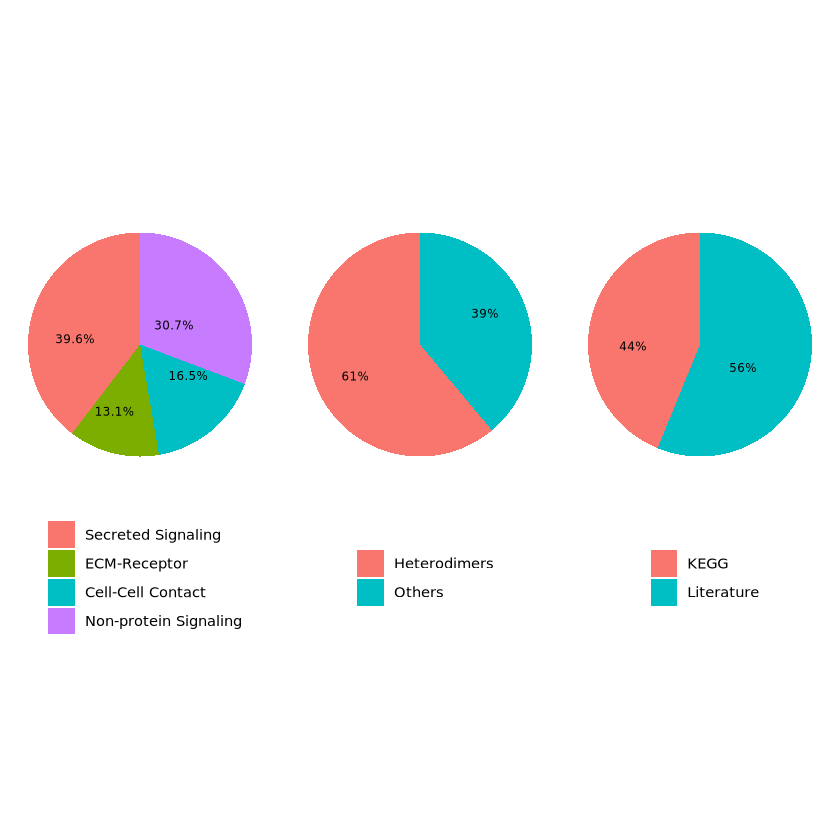

In [11]:
CellChatDB <- CellChatDB.human # use CellChatDB.mouse if running on mouse data
showDatabaseCategory(CellChatDB)

In [12]:
# Show the structure of the database
# dplyr::glimpse(CellChatDB$interaction)

# use a subset of CellChatDB for cell-cell communication analysis
# CellChatDB.use <- subsetDB(CellChatDB, search = "Secreted Signaling", key = "annotation") # use Secreted Signaling

# Only uses the Secreted Signaling from CellChatDB v1
#  CellChatDB.use <- subsetDB(CellChatDB, search = list(c("Secreted Signaling"), c("CellChatDB v1")), key = c("annotation", "version"))

# use all CellChatDB except for "Non-protein Signaling" for cell-cell communication analysis
CellChatDB.use <- subsetDB(CellChatDB)


# use all CellChatDB for cell-cell communication analysis
# CellChatDB.use <- CellChatDB # simply use the default CellChatDB. We do not suggest to use it in this way because CellChatDB v2 includes "Non-protein Signaling" (i.e., metabolic and synaptic signaling). 

# set the used database in the object
cellchat@DB <- CellChatDB

In [14]:
# save the cell chat object
cellchat %>% saveRDS(file.path(output_path, 'ALTRA_AIM3_TB_cellchat.rds'))

In [4]:
cellchat <- readRDS(file.path(output_path, 'ALTRA_AIM3_TB_cellchat.rds'))

In [13]:
options(future.globals.maxSize= 20000 * 1024^2)

In [7]:
# subset the expression data of signaling genes for saving computation cost
cellchat <- subsetData(cellchat) # This step is necessary even if using the whole database
future::plan("multisession", workers = 30) # do parallel
cellchat <- identifyOverExpressedGenes(cellchat)
cellchat <- identifyOverExpressedInteractions(cellchat)

# project gene expression data onto PPI (Optional: when running it, USER should set `raw.use = FALSE` in the function `computeCommunProb()` in order to use the projected data)
# cellchat <- projectData(cellchat, PPI.human)

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 2.6 GiB”


The number of highly variable ligand-receptor pairs used for signaling inference is 2668 


ERROR: Error: object 'ptm' not found


In [8]:
cellchat

An object of class CellChat created from a single dataset 
 33538 genes.
 247306 cells. 
CellChat analysis of single cell RNA-seq data! 

In [ ]:
ptm = Sys.time()
cellchat <- computeCommunProb(cellchat, type = "triMean" )

triMean is used for calculating the average gene expression per cell group. 


Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 2.6 GiB”


In [ ]:
cellchat <- filterCommunication(cellchat, min.cells = 10)

In [ ]:
# save the cell chat object
cellchat %>% saveRDS(file.path(output_path, 'ALTRA_AIM3_TB_cellchat.rds'))